In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [5]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.78MB/s]

Training samples: 60000
Testing samples: 10000


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 938
Number of testing batches: 157


In [7]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
First 10 labels: tensor([7, 9, 8, 8, 0, 3, 2, 5, 1, 3])


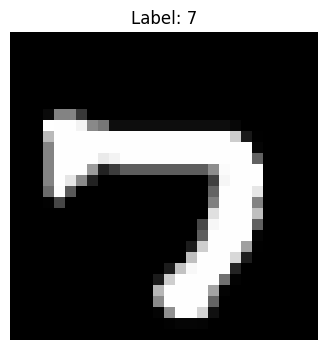

In [8]:
plt.figure(figsize=(4, 4))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")

plt.show()

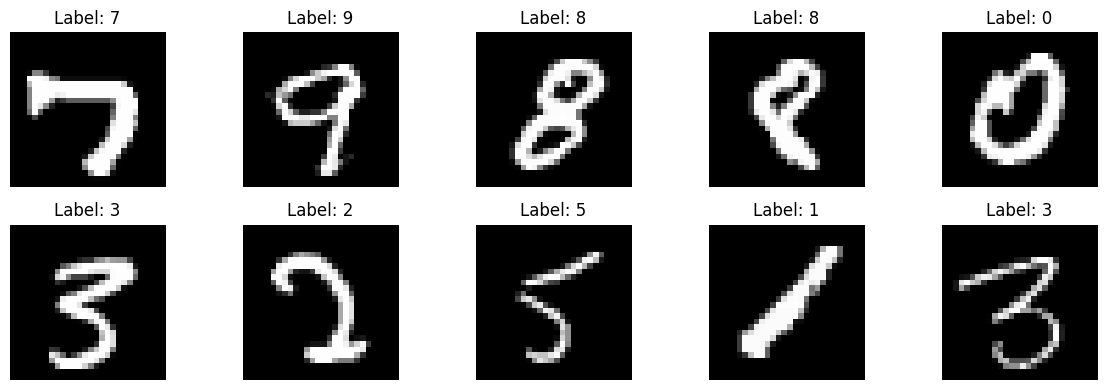

In [9]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print("Minimum pixel value:", images[0].min().item())
print("Maximum pixel value:", images[0].max().item())
print("Image shape:", images[0].shape)

Minimum pixel value: -1.0
Maximum pixel value: 0.9921568632125854
Image shape: torch.Size([1, 28, 28])


In [11]:
class MiniDigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [12]:
model = MiniDigitCNN().to(device)

print(model)

MiniDigitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
total_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_params)

Trainable parameters: 206922


In [14]:
model.eval()

with torch.no_grad():
    sample_image = images[0].unsqueeze(0).to(device)
    output = model(sample_image)

predicted_digit = output.argmax(dim=1).item()

print("Actual digit:", labels[0].item())
print("Predicted digit:", predicted_digit)

Actual digit: 7
Predicted digit: 2


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [16]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        # Forward pass
        outputs = model(images_batch)

        # Calculate loss
        loss = criterion(outputs, labels_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 0.2029
Epoch [2/5], Loss: 0.0556
Epoch [3/5], Loss: 0.0392
Epoch [4/5], Loss: 0.0299
Epoch [5/5], Loss: 0.0235


In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images_batch, labels_batch in test_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)

        predictions = outputs.argmax(dim=1)

        total += labels_batch.size(0)
        correct += (predictions == labels_batch).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.12%


In [18]:
model.eval()

test_image, test_label = test_dataset[0]

with torch.no_grad():
    input_image = test_image.unsqueeze(0).to(device)

    output = model(input_image)

    prediction = output.argmax(dim=1).item()

print("Actual digit:", test_label)
print("Predicted digit:", prediction)

Actual digit: 7
Predicted digit: 7


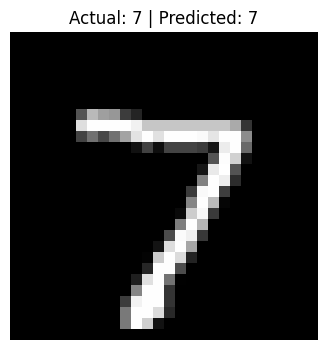

In [19]:
plt.figure(figsize=(4, 4))

plt.imshow(test_image.squeeze(), cmap="gray")

plt.title(
    f"Actual: {test_label} | Predicted: {prediction}"
)

plt.axis("off")
plt.show()

In [20]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images_batch, labels_batch in test_loader:

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)
        predictions = outputs.argmax(dim=1)

        wrong_mask = predictions != labels_batch

        wrong_images.extend(
            images_batch[wrong_mask].cpu()
        )

        wrong_labels.extend(
            labels_batch[wrong_mask].cpu()
        )

        wrong_predictions.extend(
            predictions[wrong_mask].cpu()
        )

print("Wrong predictions:", len(wrong_images))

Wrong predictions: 88


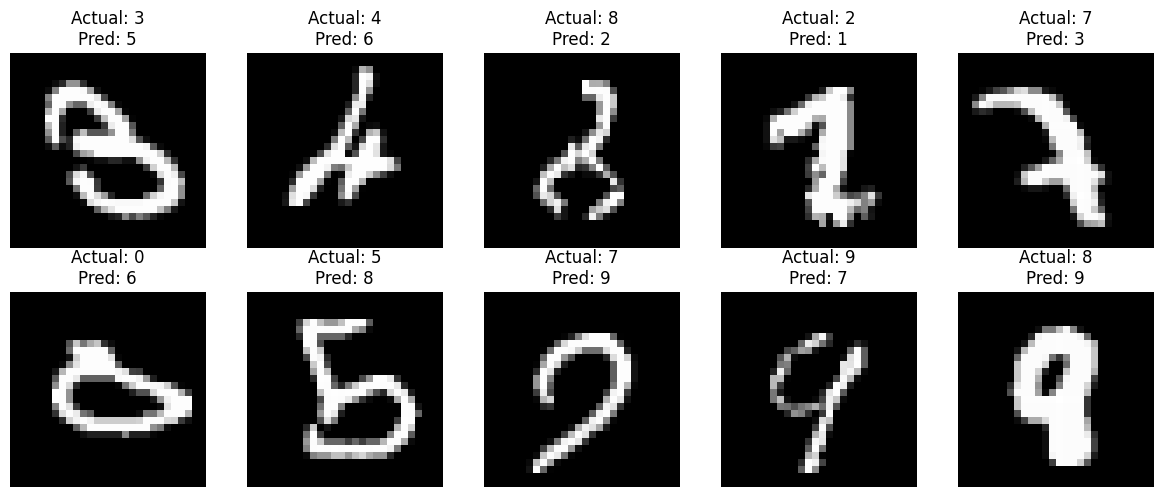

In [21]:
plt.figure(figsize=(12, 5))

for i in range(min(10, len(wrong_images))):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {wrong_labels[i].item()}\n"
        f"Pred: {wrong_predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()